# Quantization of Qwen3-0.6B-Base

This notebook compares the original weights with 8-, 4-, 3-, and 2-bit approximations on ten multiple-choice tasks. Install the dependencies and select **Run All**. Results are saved to `qwen_results/`.


In [1]:
# Uncomment and run once if dependencies are missing, then restart the kernel.
# %pip install -q torch==2.11.0 transformers==5.16.1 numpy==2.2.6 pandas==2.2.3 matplotlib==3.10.0 ipython==9.0.2 jinja2==3.1.6


## 1. Configuration


In [2]:
import gc
import json
import time
from datetime import datetime
from html import escape
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from IPython.display import FileLink, display
from matplotlib.ticker import PercentFormatter
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B-Base"
MODEL_REVISION = "da87bfb608c14b7cf20ba1ce41287e8de496c0cd"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DTYPE = (
    torch.bfloat16
    if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
    else torch.float32
)
SEED = 42
BATCH_SIZE = 16
EPS = 1e-06
RESULTS_FOLDER = Path("qwen_results")
DETAIL_TASK = "F01"
BASELINE_LABEL = {torch.float32: "FP32", torch.bfloat16: "BF16", torch.float16: "FP16"}[
    MODEL_DTYPE
]
PRECISIONS = [
    (BASELINE_LABEL, None),
    ("8-bit", 8),
    ("4-bit", 4),
    ("3-bit", 3),
    ("2-bit", 2),
]
PRECISION_ORDER = [label for label, _ in PRECISIONS]
np.random.seed(SEED)
torch.manual_seed(SEED)
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)


## 2. Ten tasks

Each task has four candidate answers and one correct answer.


In [3]:
TASKS = [
    {
        "task_index": 1,
        "task_id": "F01",
        "task_name": "Capital of Bulgaria",
        "prompt": "The capital of Bulgaria is",
        "correct": "Sofia",
        "candidates": ["Sofia", "Veliko Tarnovo", "Plovdiv", "London"],
    },
    {
        "task_index": 2,
        "task_id": "F02",
        "task_name": "Mendeleev and the periodic table",
        "prompt": "The Russian chemist who developed the periodic table was",
        "correct": "Dmitri Mendeleev",
        "candidates": [
            "Dmitri Mendeleev",
            "Alexander Butlerov",
            "Ivan Pavlov",
            "Mikhail Lomonosov",
        ],
    },
    {
        "task_index": 3,
        "task_id": "F03",
        "task_name": "Land border of China",
        "prompt": "China shares a land border with",
        "correct": "North Korea",
        "candidates": ["Bulgaria", "North Korea", "South Korea", "Japan"],
    },
    {
        "task_index": 4,
        "task_id": "F04",
        "task_name": "Euler's number",
        "prompt": "Euler's number (Napier's constant) is approximately",
        "correct": "2.72",
        "candidates": ["2.72", "3.14", "3.72", "2.14"],
    },
    {
        "task_index": 5,
        "task_id": "F05",
        "task_name": "45th President of the United States",
        "prompt": "The 45th President of the United States was",
        "correct": "Donald Trump",
        "candidates": [
            "Barron Trump",
            "Donald Trump",
            "Henry Kissinger",
            "Benjamin Franklin",
        ],
    },
    {
        "task_index": 6,
        "task_id": "C01",
        "task_name": "Seven plus eleven",
        "prompt": "Seven plus eleven equals",
        "correct": "18",
        "candidates": ["14", "18", "711", "117"],
    },
    {
        "task_index": 7,
        "task_id": "F06",
        "task_name": "Highest mountain",
        "prompt": "The highest mountain on Earth above sea level is",
        "correct": "Mount Everest",
        "candidates": ["Mount Everest", "Mount Elbrus", "K2", "Vihren"],
    },
    {
        "task_index": 8,
        "task_id": "F07",
        "task_name": "Largest planet",
        "prompt": "The largest planet in the Solar System is",
        "correct": "Jupiter",
        "candidates": ["Jupiter", "Saturn", "Earth", "Pluto"],
    },
    {
        "task_index": 9,
        "task_id": "F08",
        "task_name": "The Red Planet",
        "prompt": "The Red Planet is another name for",
        "correct": "Mars",
        "candidates": ["Mars", "Earth", "Jupiter", "Saturn"],
    },
    {
        "task_index": 10,
        "task_id": "F09",
        "task_name": "Chemical formula of water",
        "prompt": "The chemical formula of water is",
        "correct": "H2O",
        "candidates": ["H2O", "CO2", "O2", "NaCl"],
    },
]
cases = pd.DataFrame(TASKS).sort_values("task_index").reset_index(drop=True)
display(
    cases.rename(
        columns={
            "task_index": "Number",
            "task_id": "ID",
            "task_name": "Task",
            "prompt": "Prompt",
            "correct": "Correct answer",
            "candidates": "Candidates",
        }
    ).style.hide(axis="index")
)


Number,ID,Task,Prompt,Correct answer,Candidates
1,F01,Capital of Bulgaria,The capital of Bulgaria is,Sofia,"['Sofia', 'Veliko Tarnovo', 'Plovdiv', 'London']"
2,F02,Mendeleev and the periodic table,The Russian chemist who developed the periodic table was,Dmitri Mendeleev,"['Dmitri Mendeleev', 'Alexander Butlerov', 'Ivan Pavlov', 'Mikhail Lomonosov']"
3,F03,Land border of China,China shares a land border with,North Korea,"['Bulgaria', 'North Korea', 'South Korea', 'Japan']"
4,F04,Euler's number,Euler's number (Napier's constant) is approximately,2.72,"['2.72', '3.14', '3.72', '2.14']"
5,F05,45th President of the United States,The 45th President of the United States was,Donald Trump,"['Barron Trump', 'Donald Trump', 'Henry Kissinger', 'Benjamin Franklin']"
6,C01,Seven plus eleven,Seven plus eleven equals,18,"['14', '18', '711', '117']"
7,F06,Highest mountain,The highest mountain on Earth above sea level is,Mount Everest,"['Mount Everest', 'Mount Elbrus', 'K2', 'Vihren']"
8,F07,Largest planet,The largest planet in the Solar System is,Jupiter,"['Jupiter', 'Saturn', 'Earth', 'Pluto']"
9,F08,The Red Planet,The Red Planet is another name for,Mars,"['Mars', 'Earth', 'Jupiter', 'Saturn']"
10,F09,Chemical formula of water,The chemical formula of water is,H2O,"['H2O', 'CO2', 'O2', 'NaCl']"


## 3. Quantization examples

Ten values are rounded to grids with different bit widths. Each grid uses one scale for the whole vector. The symmetric 2-bit grid has three levels.


In [4]:
def quantize_vector_symmetric(values, bits):
    values = np.asarray(values, dtype=np.float32)
    qmax = 2 ** (bits - 1) - 1
    scale = float(np.max(np.abs(values)) / qmax)
    if scale == 0:
        integer_codes = np.zeros_like(values, dtype=np.int32)
        quantized = values.copy()
    else:
        integer_codes = np.clip(np.round(values / scale), -qmax, qmax).astype(np.int32)
        quantized = integer_codes.astype(np.float32) * scale
    quantized[np.abs(quantized) < 1e-12] = 0.0
    error = np.abs(values - quantized)
    return {
        "qmax": qmax,
        "levels": 2 * qmax + 1,
        "scale": scale,
        "integer_codes": integer_codes,
        "quantized": quantized,
        "mean_error": float(error.mean()),
        "max_error": float(error.max()),
    }


demo_weights = np.array(
    [-1.0, -0.73, -0.41, -0.18, -0.04, 0.07, 0.22, 0.46, 0.71, 1.0], dtype=np.float32
)
demo = {bits: quantize_vector_symmetric(demo_weights, bits) for bits in [8, 4, 3, 2]}
grid_table = pd.DataFrame(
    [
        {
            "Bits": bits,
            "qmax": result["qmax"],
            "Levels": result["levels"],
            "Scale": result["scale"],
            "Mean absolute error": result["mean_error"],
            "Maximum absolute error": result["max_error"],
        }
        for bits, result in demo.items()
    ]
)
display(grid_table.round(6).style.hide(axis="index"))
value_table = pd.DataFrame(
    {
        "Input value (FP32)": demo_weights,
        **{
            f"{bits}-bit approximation": result["quantized"]
            for bits, result in demo.items()
        },
    }
)
display(value_table.round(3).style.hide(axis="index"))


Bits,qmax,Levels,Scale,Mean absolute error,Maximum absolute error
8,127,255,0.007874,0.001055,0.003307
4,7,15,0.142857,0.028286,0.070000
3,3,7,0.333333,0.068667,0.153333
2,1,3,1.000000,0.194000,0.460000


Input value (FP32),8-bit approximation,4-bit approximation,3-bit approximation,2-bit approximation
-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
-0.730000,-0.732000,-0.714000,-0.667000,-1.000000
-0.410000,-0.409000,-0.429000,-0.333000,0.000000
-0.180000,-0.181000,-0.143000,-0.333000,0.000000
-0.040000,-0.039000,0.000000,0.000000,0.000000
0.070000,0.071000,0.000000,0.000000,0.000000
0.220000,0.220000,0.286000,0.333000,0.000000
0.460000,0.457000,0.429000,0.333000,0.000000
0.710000,0.709000,0.714000,0.667000,1.000000
1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Load and quantize the model

Only attention and MLP linear weights are quantized, with a separate scale for each row. Each setting starts from the original weights, which are restored after the experiment. The approximated weights remain floating-point tensors.


In [5]:
if "model" in globals():
    del model
TARGET_MODULES = {}
ORIGINAL_WEIGHTS = {}
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, use_fast=True
)
tokenizer.padding_side = "right"
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, dtype=MODEL_DTYPE
).to(DEVICE)
model.eval()
TARGET_SUFFIXES = (
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj",
)
TARGET_MODULES = {
    name: module
    for name, module in model.named_modules()
    if isinstance(module, nn.Linear) and name.endswith(TARGET_SUFFIXES)
}
ORIGINAL_WEIGHTS = {
    name: module.weight.detach().clone() for name, module in TARGET_MODULES.items()
}


@torch.no_grad()
def quantize_tensor_symmetric_rtn(original, bits):
    qmax = 2 ** (bits - 1) - 1
    weights = original.float()
    scale = weights.abs().amax(dim=1, keepdim=True).clamp_min(1e-08) / qmax
    integer_codes = torch.round(weights / scale).clamp(-qmax, qmax)
    return integer_codes * scale


@torch.no_grad()
def set_precision(bits=None):
    for name, module in TARGET_MODULES.items():
        original = ORIGINAL_WEIGHTS[name]
        if bits is None:
            module.weight.copy_(original)
        else:
            quantized = quantize_tensor_symmetric_rtn(original, bits)
            module.weight.copy_(quantized.to(module.weight.dtype))


parameter_count = sum((p.numel() for p in model.parameters()))
quantized_parameter_count = sum(
    (module.weight.numel() for module in TARGET_MODULES.values())
)
print(f"Device: {DEVICE}; baseline: {BASELINE_LABEL}")
print(f"PyTorch: {torch.__version__}; Transformers: {transformers.__version__}")
print(f"Parameters: {parameter_count:,}")
print(
    f"Quantized matrices: {len(TARGET_MODULES)}; weights: {quantized_parameter_count:,} ({quantized_parameter_count / parameter_count:.1%})"
)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Device: cpu; baseline: FP32
PyTorch: 2.11.0+cpu; Transformers: 5.16.1
Parameters: 596,049,920
Quantized matrices: 196; weights: 440,401,920 (73.9%)


## 5. Score the candidate answers

Each candidate is scored by the average log-probability of its tokens. Softmax converts these scores into relative scores among the four candidates. A correct answer counts toward accuracy only if it ranks first without a tie.


In [6]:
def build_scoring_items(cases_frame):
    items = []
    for row in cases_frame.itertuples(index=False):
        prompt_ids = tokenizer.encode(row.prompt, add_special_tokens=False)
        for candidate_index, candidate in enumerate(row.candidates, start=1):
            candidate_text = " " + candidate
            candidate_ids = tokenizer.encode(candidate_text, add_special_tokens=False)
            full_text = row.prompt + candidate_text
            full_ids = tokenizer.encode(full_text, add_special_tokens=False)
            if full_ids != prompt_ids + candidate_ids:
                raise ValueError(
                    f"Unexpected tokenization boundary: {row.prompt!r} + {candidate!r}"
                )
            items.append(
                {
                    "task_index": row.task_index,
                    "task_id": row.task_id,
                    "task_name": row.task_name,
                    "prompt": row.prompt,
                    "correct_answer": row.correct,
                    "candidate_index": candidate_index,
                    "candidate": candidate,
                    "is_correct_candidate": candidate == row.correct,
                    "full_text": full_text,
                    "prompt_ids": prompt_ids,
                    "candidate_ids": candidate_ids,
                    "input_ids": full_ids,
                    "token_pieces": tokenizer.convert_ids_to_tokens(candidate_ids),
                    "token_texts": [
                        tokenizer.decode([token_id], clean_up_tokenization_spaces=False)
                        for token_id in candidate_ids
                    ],
                }
            )
    return items


def add_group_metrics(frame):
    frame = frame.copy()
    group_columns = ["precision_index", "precision", "task_index", "task_id"]
    frame["normalized_score"] = frame.groupby(group_columns)["mean_logprob"].transform(
        lambda values: np.exp(values - values.max())
        / np.exp(values - values.max()).sum()
    )
    frame["rank"] = (
        frame.groupby(group_columns)["mean_logprob"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    group_max = frame.groupby(group_columns)["mean_logprob"].transform("max")
    frame["is_top_score"] = (frame["mean_logprob"] - group_max).abs() <= EPS
    frame["top_tie_count"] = (
        frame.groupby(group_columns)["is_top_score"].transform("sum").astype(int)
    )
    top_candidates = (
        frame[frame["is_top_score"]]
        .groupby(group_columns, as_index=False)["candidate"]
        .agg(" | ".join)
        .rename(columns={"candidate": "top_candidates"})
    )
    correct = frame[frame["is_correct_candidate"]][
        group_columns + ["mean_logprob"]
    ].rename(columns={"mean_logprob": "correct_mean_logprob"})
    best_wrong = (
        frame[~frame["is_correct_candidate"]]
        .groupby(group_columns, as_index=False)["mean_logprob"]
        .max()
        .rename(columns={"mean_logprob": "best_wrong_mean_logprob"})
    )
    metrics = correct.merge(best_wrong, on=group_columns, validate="one_to_one")
    metrics["margin_to_best_wrong"] = (
        metrics["correct_mean_logprob"] - metrics["best_wrong_mean_logprob"]
    )
    metrics["correct_is_unique_top1"] = metrics["margin_to_best_wrong"] > EPS
    metrics["correct_is_tied_top1"] = metrics["margin_to_best_wrong"].abs() <= EPS
    return frame.merge(top_candidates, on=group_columns, validate="many_to_one").merge(
        metrics, on=group_columns, validate="many_to_one"
    )


@torch.no_grad()
def score_current_model(precision, quantization_bits, precision_index):
    rows = []
    for start in range(0, len(SCORING_ITEMS), BATCH_SIZE):
        batch = SCORING_ITEMS[start : start + BATCH_SIZE]
        max_length = max((len(item["input_ids"]) for item in batch))
        input_ids = torch.full(
            (len(batch), max_length),
            tokenizer.pad_token_id,
            dtype=torch.long,
            device=DEVICE,
        )
        attention_mask = torch.zeros_like(input_ids)
        for batch_index, item in enumerate(batch):
            ids = torch.tensor(item["input_ids"], dtype=torch.long, device=DEVICE)
            input_ids[batch_index, : len(ids)] = ids
            attention_mask[batch_index, : len(ids)] = 1
        logits = model(
            input_ids=input_ids, attention_mask=attention_mask, use_cache=False
        ).logits
        for batch_index, item in enumerate(batch):
            prompt_length = len(item["prompt_ids"])
            candidate_ids = item["candidate_ids"]
            positions = torch.arange(
                prompt_length - 1, prompt_length - 1 + len(candidate_ids), device=DEVICE
            )
            candidate_logits = logits[batch_index, positions, :].float()
            targets = torch.tensor(candidate_ids, dtype=torch.long, device=DEVICE)
            token_logprobs_tensor = (
                F.log_softmax(candidate_logits, dim=-1)
                .gather(1, targets[:, None])
                .squeeze(1)
            )
            token_logprobs = [float(value) for value in token_logprobs_tensor.cpu()]
            token_probabilities = [float(np.exp(value)) for value in token_logprobs]
            rows.append(
                {
                    "precision_index": precision_index,
                    "precision": precision,
                    "quantization_bits": quantization_bits,
                    "quantization_method": (
                        "none"
                        if quantization_bits is None
                        else "symmetric per-output-channel RTN"
                    ),
                    "task_index": item["task_index"],
                    "task_id": item["task_id"],
                    "task_name": item["task_name"],
                    "prompt": item["prompt"],
                    "correct_answer": item["correct_answer"],
                    "candidate_index": item["candidate_index"],
                    "candidate": item["candidate"],
                    "is_correct_candidate": item["is_correct_candidate"],
                    "full_text": item["full_text"],
                    "prompt_token_count": len(item["prompt_ids"]),
                    "candidate_token_count": len(candidate_ids),
                    "token_pieces": item["token_pieces"],
                    "token_texts": item["token_texts"],
                    "token_ids": candidate_ids,
                    "token_logprobs": token_logprobs,
                    "token_probabilities": token_probabilities,
                    "sum_logprob": float(token_logprobs_tensor.sum().item()),
                    "mean_logprob": float(token_logprobs_tensor.mean().item()),
                }
            )
    return add_group_metrics(pd.DataFrame(rows))


SCORING_ITEMS = build_scoring_items(cases)


## 6. Run the experiment and save the results


In [7]:
result_parts = []
try:
    for precision_index, (precision, bits) in enumerate(PRECISIONS):
        set_precision(bits)
        run_started = time.time()
        part = score_current_model(
            precision=precision, quantization_bits=bits, precision_index=precision_index
        )
        result_parts.append(part)
        correct_part = part[part["is_correct_candidate"]]
        correct_count = int(correct_part["correct_is_unique_top1"].sum())
        print(
            f"{precision}: {correct_count}/{len(cases)} correct; {time.time() - run_started:.1f} s"
        )
finally:
    set_precision(None)
results = (
    pd.concat(result_parts, ignore_index=True)
    .sort_values(["precision_index", "task_index", "candidate_index"])
    .reset_index(drop=True)
)
results.insert(0, "row_number", np.arange(1, len(results) + 1))
csv_results = results.copy()
for column in [
    "token_pieces",
    "token_texts",
    "token_ids",
    "token_logprobs",
    "token_probabilities",
]:
    csv_results[column] = csv_results[column].map(
        lambda values: json.dumps(values, ensure_ascii=False)
    )
expected_rows = len(PRECISIONS) * len(SCORING_ITEMS)
if len(results) != expected_rows:
    raise RuntimeError(f"Expected {expected_rows} result rows, got {len(results)}.")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_FILE = RESULTS_FOLDER / f"results_{timestamp}.csv"
csv_results.to_csv(RESULTS_FILE, index=False)
print(f"Saved {len(results)} rows to {RESULTS_FILE}")
display(FileLink(str(RESULTS_FILE)))


FP32: 10/10 correct; 28.3 s
8-bit: 10/10 correct; 16.3 s
4-bit: 9/10 correct; 13.5 s
3-bit: 1/10 correct; 15.0 s
2-bit: 6/10 correct; 17.1 s
Saved 200 rows to qwen_results/results_20260909_141602.csv


/content/qwen_results/results_20260909_141602.csv

## 7. Baseline answers


In [8]:
baseline = results[results["precision"] == BASELINE_LABEL]
baseline_correct_rows = (
    baseline[baseline["is_correct_candidate"]].sort_values("task_index").copy()
)
baseline_correct_rows["Status"] = np.where(
    baseline_correct_rows["correct_is_unique_top1"],
    "✓ correct",
    np.where(baseline_correct_rows["correct_is_tied_top1"], "≈ tie", "✗ incorrect"),
)
display(
    baseline_correct_rows[
        [
            "task_id",
            "task_name",
            "correct_answer",
            "top_candidates",
            "margin_to_best_wrong",
            "Status",
        ]
    ]
    .rename(
        columns={
            "task_id": "ID",
            "task_name": "Task",
            "correct_answer": "Correct answer",
            "top_candidates": "Baseline top candidates",
            "margin_to_best_wrong": "Margin",
        }
    )
    .style.format({"Margin": "{:.4f}"})
    .hide(axis="index")
)


ID,Task,Correct answer,Baseline top candidates,Margin,Status
F01,Capital of Bulgaria,Sofia,Sofia,0.4456,✓ correct
F02,Mendeleev and the periodic table,Dmitri Mendeleev,Dmitri Mendeleev,0.8600,✓ correct
F03,Land border of China,North Korea,North Korea,0.6650,✓ correct
F04,Euler's number,2.72,2.72,0.2816,✓ correct
F05,45th President of the United States,Donald Trump,Donald Trump,0.9079,✓ correct
C01,Seven plus eleven,18,18,0.4696,✓ correct
F06,Highest mountain,Mount Everest,Mount Everest,1.3080,✓ correct
F07,Largest planet,Jupiter,Jupiter,2.2475,✓ correct
F08,The Red Planet,Mars,Mars,1.8318,✓ correct
F09,Chemical formula of water,H2O,H2O,2.8232,✓ correct


## 8. Candidate and token details

These tables show the baseline scores for one task. Each answer is evaluated using all its tokens.


In [9]:
baseline_detail = (
    baseline[baseline["task_id"] == DETAIL_TASK].sort_values("candidate_index").copy()
)
display(
    baseline_detail[
        [
            "candidate",
            "candidate_token_count",
            "sum_logprob",
            "mean_logprob",
            "normalized_score",
            "rank",
            "is_correct_candidate",
        ]
    ]
    .rename(
        columns={
            "candidate": "Candidate",
            "candidate_token_count": "Token count",
            "sum_logprob": "Sum logprob",
            "mean_logprob": "Mean logprob",
            "normalized_score": "Relative score (4 candidates)",
            "rank": "Rank",
            "is_correct_candidate": "Correct?",
        }
    )
    .style.format(
        {
            "Sum logprob": "{:.4f}",
            "Mean logprob": "{:.4f}",
            "Relative score (4 candidates)": "{:.1%}",
        }
    )
    .hide(axis="index")
)
token_rows = []
for row in baseline_detail.itertuples(index=False):
    for token_index, (
        token_piece,
        token_text,
        token_id,
        token_logprob,
        token_probability,
    ) in enumerate(
        zip(
            row.token_pieces,
            row.token_texts,
            row.token_ids,
            row.token_logprobs,
            row.token_probabilities,
        ),
        start=1,
    ):
        token_rows.append(
            {
                "Candidate": row.candidate,
                "Correct candidate?": row.is_correct_candidate,
                "Token number": token_index,
                "Token piece": token_piece,
                "Decoded text": token_text,
                "Token ID": token_id,
                "Probability": token_probability,
                "Logprob": token_logprob,
            }
        )
token_detail = pd.DataFrame(token_rows)
display(
    token_detail.style.format({"Probability": "{:.4%}", "Logprob": "{:.4f}"}).hide(
        axis="index"
    )
)


Candidate,Token count,Sum logprob,Mean logprob,Relative score (4 candidates),Rank,Correct?
Sofia,1,-1.3840,-1.3840,51.2%,1,True
Veliko Tarnovo,5,-9.1477,-1.8295,32.8%,2,False
Plovdiv,3,-7.6504,-2.5501,16.0%,3,False
London,1,-8.4829,-8.4829,0.0%,4,False


Candidate,Correct candidate?,Token number,Token piece,Decoded text,Token ID,Probability,Logprob
Sofia,True,1,ĠSofia,Sofia,78563,25.0578%,-1.3840
Veliko Tarnovo,False,1,ĠVel,Vel,30198,0.0173%,-8.6616
Veliko Tarnovo,False,2,iko,iko,23630,70.5885%,-0.3483
Veliko Tarnovo,False,3,ĠT,T,350,95.5804%,-0.0452
Veliko Tarnovo,False,4,arn,arn,1885,92.9638%,-0.0730
Veliko Tarnovo,False,5,ovo,ovo,21715,98.0490%,-0.0197
Plovdiv,False,1,ĠP,P,393,0.0554%,-7.4979
Plovdiv,False,2,lov,lov,35147,85.9073%,-0.1519
Plovdiv,False,3,div,div,611,99.9471%,-0.0005
London,False,1,ĠLondon,London,7148,0.0207%,-8.4829


## 9. Accuracy across precisions


Precision,Score,Accuracy
FP32,10/10,100.0%
8-bit,10/10,100.0%
4-bit,9/10,90.0%
3-bit,1/10,10.0%
2-bit,6/10,60.0%


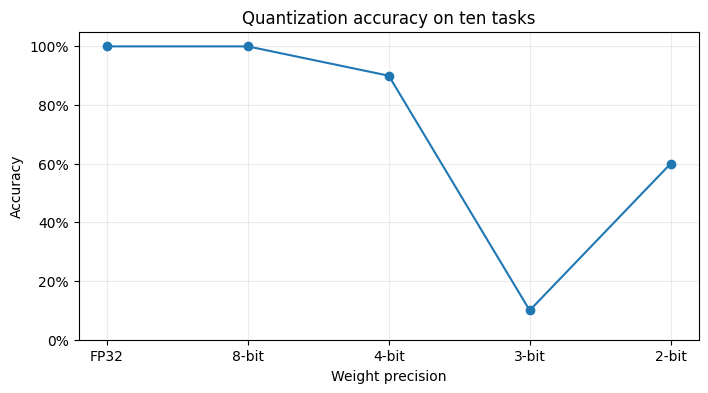

In [10]:
correct_rows = results[results["is_correct_candidate"]].copy()
summary = (
    correct_rows.groupby(["precision_index", "precision"], as_index=False)
    .agg(
        correct_tasks=("correct_is_unique_top1", "sum"),
        total_tasks=("task_id", "nunique"),
    )
    .sort_values("precision_index")
    .reset_index(drop=True)
)
summary["accuracy"] = summary["correct_tasks"] / summary["total_tasks"]
summary_display = summary.copy()
summary_display["Score"] = (
    summary_display["correct_tasks"].astype(int).astype(str)
    + "/"
    + summary_display["total_tasks"].astype(int).astype(str)
)
summary_display["Accuracy"] = summary_display["accuracy"].map(
    lambda value: f"{value:.1%}"
)
display(
    summary_display[["precision", "Score", "Accuracy"]]
    .rename(columns={"precision": "Precision"})
    .style.hide(axis="index")
)
plt.figure(figsize=(8, 4))
plt.plot(summary["precision"], summary["accuracy"], marker="o")
plt.ylim(0, 1.05)
plt.xlabel("Weight precision")
plt.ylabel("Accuracy")
plt.title("Quantization accuracy on ten tasks")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(alpha=0.25)
plt.show()


## 10. Selected answers for every task


In [11]:
status_rows = correct_rows[
    [
        "precision_index",
        "precision",
        "task_index",
        "task_id",
        "task_name",
        "correct_answer",
        "top_candidates",
        "correct_is_unique_top1",
        "correct_is_tied_top1",
    ]
].copy()
status_rows["status"] = np.where(
    status_rows["correct_is_unique_top1"],
    "✓ " + status_rows["correct_answer"],
    np.where(
        status_rows["correct_is_tied_top1"],
        "≈ " + status_rows["top_candidates"],
        "✗ " + status_rows["top_candidates"],
    ),
)
status_table = (
    status_rows.pivot(
        index=["task_index", "task_id", "task_name"],
        columns="precision",
        values="status",
    )
    .reindex(columns=PRECISION_ORDER)
    .sort_index()
)


def format_cell(value: object) -> str:
    text = escape(str(value))
    if text.startswith("✗"):
        return '<span style="color: red; font-weight: bold;">✗</span>' + text[1:]
    return text


display(
    status_table.reset_index()
    .rename(columns={"task_index": "Number", "task_id": "ID", "task_name": "Task"})
    .style.format(format_cell, escape=None, na_rep="")
    .hide(axis="index")
)


Number,ID,Task,FP32,8-bit,4-bit,3-bit,2-bit
1,F01,Capital of Bulgaria,✓ Sofia,✓ Sofia,✓ Sofia,✗ Veliko Tarnovo,✗ London
2,F02,Mendeleev and the periodic table,✓ Dmitri Mendeleev,✓ Dmitri Mendeleev,✓ Dmitri Mendeleev,✗ Mikhail Lomonosov,✗ Ivan Pavlov
3,F03,Land border of China,✓ North Korea,✓ North Korea,✓ North Korea,✓ North Korea,✓ North Korea
4,F04,Euler's number,✓ 2.72,✓ 2.72,✓ 2.72,✗ 2.14,✓ 2.72
5,F05,45th President of the United States,✓ Donald Trump,✓ Donald Trump,✓ Donald Trump,✗ Barron Trump,✗ Benjamin Franklin
6,C01,Seven plus eleven,✓ 18,✓ 18,✓ 18,✗ 117,✓ 18
7,F06,Highest mountain,✓ Mount Everest,✓ Mount Everest,✓ Mount Everest,✗ K2,✓ Mount Everest
8,F07,Largest planet,✓ Jupiter,✓ Jupiter,✓ Jupiter,✗ Earth,✓ Jupiter
9,F08,The Red Planet,✓ Mars,✓ Mars,✗ Earth,✗ Earth,✗ Earth
10,F09,Chemical formula of water,✓ H2O,✓ H2O,✓ H2O,✗ CO2,✓ H2O


## 11. Candidate scores across precisions


Precision,Candidate,Token count,Sum logprob,Mean logprob,Relative score (4 candidates),Rank,Correct?
FP32,Sofia,1,-1.3840,-1.3840,51.2%,1,True
FP32,Veliko Tarnovo,5,-9.1477,-1.8295,32.8%,2,False
FP32,Plovdiv,3,-7.6504,-2.5501,16.0%,3,False
FP32,London,1,-8.4829,-8.4829,0.0%,4,False
8-bit,Sofia,1,-1.4220,-1.4220,49.7%,1,True
8-bit,Veliko Tarnovo,5,-9.0445,-1.8089,33.8%,2,False
8-bit,Plovdiv,3,-7.5878,-2.5293,16.4%,3,False
8-bit,London,1,-8.3845,-8.3845,0.0%,4,False
4-bit,Sofia,1,-1.2290,-1.2290,84.1%,1,True
4-bit,Veliko Tarnovo,5,-18.3640,-3.6728,7.3%,3,False


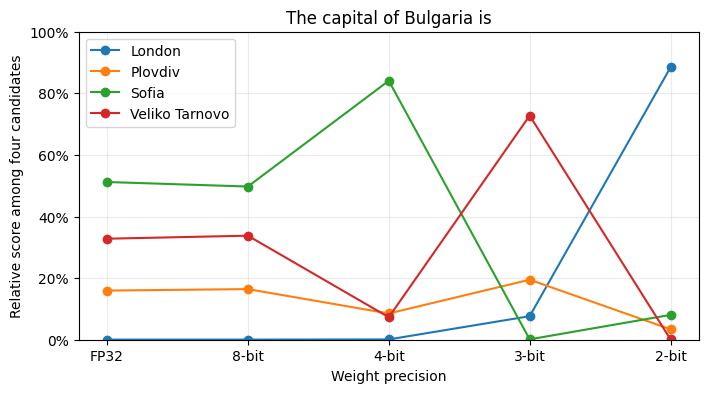

In [12]:
detail = (
    results[results["task_id"] == DETAIL_TASK]
    .sort_values(["precision_index", "candidate_index"])
    .copy()
)
detail_table = detail.pivot(
    index="precision", columns="candidate", values="normalized_score"
).reindex(PRECISION_ORDER)
display(
    detail[
        [
            "precision",
            "candidate",
            "candidate_token_count",
            "sum_logprob",
            "mean_logprob",
            "normalized_score",
            "rank",
            "is_correct_candidate",
        ]
    ]
    .rename(
        columns={
            "precision": "Precision",
            "candidate": "Candidate",
            "candidate_token_count": "Token count",
            "sum_logprob": "Sum logprob",
            "mean_logprob": "Mean logprob",
            "normalized_score": "Relative score (4 candidates)",
            "rank": "Rank",
            "is_correct_candidate": "Correct?",
        }
    )
    .style.format(
        {
            "Sum logprob": "{:.4f}",
            "Mean logprob": "{:.4f}",
            "Relative score (4 candidates)": "{:.1%}",
        }
    )
    .hide(axis="index")
)
plt.figure(figsize=(8, 4))
for candidate in detail_table.columns:
    plt.plot(detail_table.index, detail_table[candidate], marker="o", label=candidate)
plt.ylim(0, 1.0)
plt.xlabel("Weight precision")
plt.ylabel("Relative score among four candidates")
plt.title(cases.loc[cases["task_id"] == DETAIL_TASK, "prompt"].iloc[0])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [13]:
site = "https://www.vitoshacademy.com/python-llm-quantization-qwen3/"
print(f'Thank you for taking a look at the code. The article is available at {site}')

Thank you for taking a look at the code. The article is available at https://www.vitoshacademy.com/python-llm-quantization-qwen3/
